In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from einops import reduce

In [2]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

X, y = make_moons(n_samples=10000, noise=0.05, random_state=42)
scalar = StandardScaler()
X = scalar.fit_transform(X)


def moons_generator(batch_size):
    X, _ = make_moons(n_samples=batch_size, noise=0.05, random_state=42)
    X = scalar.transform(X)
    return X

In [3]:
from sklearn.mixture import GaussianMixture

In [4]:
clf = GaussianMixture(n_components=100, covariance_type="spherical")
clf.fit(X)

,"n_components n_components: int, default=1The number of mixture components.",100
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'spherical'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


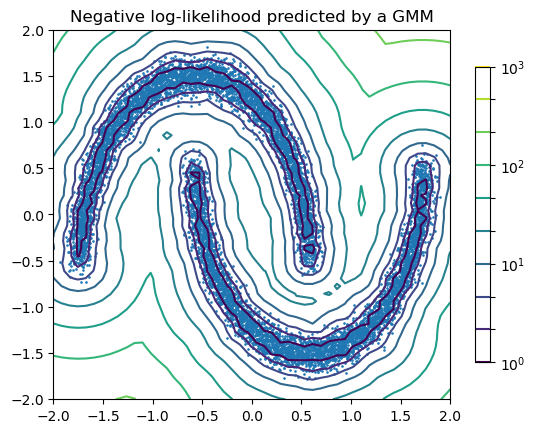

In [5]:
from matplotlib.colors import LogNorm

# display predicted scores by the model as a contour plot
x = np.linspace(-2, 2)
y = np.linspace(-2, 2)
Xgrid, Ygrid = np.meshgrid(x, y)
XYgrid = np.array([Xgrid.ravel(), Ygrid.ravel()]).T
Z = -clf.score_samples(XYgrid)
Z = Z.reshape(Xgrid.shape)

CS = plt.contour(
    Xgrid, Ygrid, Z, norm=LogNorm(vmin=1.0, vmax=1000.0), levels=np.logspace(0, 3, 10)
)
CB = plt.colorbar(CS, shrink=0.8, extend="both")
plt.scatter(X[:, 0], X[:, 1], 0.8)

plt.title("Negative log-likelihood predicted by a GMM")
plt.axis("tight")
plt.show()

In [6]:
means = torch.from_numpy(clf.means_)
sigmas = torch.sqrt(torch.from_numpy(clf.covariances_))[:, None]
weights = torch.from_numpy(clf.weights_)[:, None]

We directly compute the stochastic interpolant for $p_0\equiv 0$ to a mixture of guassians, $p_1$, where the interpolant is:
$$x_t:= t x_1+\sqrt{2 a t(1-t)}\epsilon, \quad \epsilon \sim N(0,1).$$

According to Theorem 31 (Stochastic Interpolants), the corresponding vector field is
$$ u(t, x) :=\mathbb{E}_{x_1,\epsilon}\left [tx_1 - \frac{\sqrt{2at}\epsilon}{\sqrt{1-t}}\bigg\rvert x_t=x\right]$$

And the corresponding SDE mapping $p_0$ to $p_1$ is $dX_t=u(t, X_t)dt+\sqrt{2a}dW.$

In [7]:
def get_conditional_mixture(xt, ts, means, sigmas, weights, a):
    """

    Args:
        xt: (n, dim) vector of xt
        ts: (n, 1) vector of t
        means: (m, dim) vector of mixture means
        sigmas: (m, 1) vector of mixture stds
        weights: (m, 1) mixture weights
        a: float
    """
    n, d = xt.shape
    # Make shapes common:
    xt = xt[..., None]  # (n, dim, 1)
    means = means.T[None, ...]  # (1, dim, m)
    ts_ = ts[..., None]  # (n, 1, 1)
    sigmas = sigmas.T  # (1, m)
    weights = weights.T  # (1, m)
    orig_log_weights = torch.log(weights)
    denominator = 2 * a * (1 - ts) + ts * sigmas**2  # (n, m)
    likelihood_exp_numerator = reduce((xt - means * ts_) ** 2, "n d m -> n m", "sum")
    likelihood_exp = -likelihood_exp_numerator / (2 * ts * denominator)  # (n, m)
    log_std_factor = torch.log(2 * a * (1 - ts) / denominator) * d / 2  # (n, m)
    log_rel_weights = orig_log_weights + likelihood_exp + log_std_factor
    normalization = torch.logsumexp(log_rel_weights, dim=1, keepdim=True)
    log_weights = log_rel_weights - normalization  # (n, m)
    log_weights = torch.where((ts == 0), orig_log_weights, log_weights)

    std_factor = torch.exp(log_std_factor)
    new_means = (2 * a * (1 - ts_) * means + xt * sigmas[None, ...] ** 2) / denominator[
        :, None, :
    ]  # (n, dim, m)
    new_sigmas = torch.sqrt(0.5 * std_factor * sigmas**2)  # (n, m)

    return {"log_weights": log_weights, "means": new_means, "sigmas": new_sigmas}


def drift(xt, ts, means, sigmas, weights, a):
    conditional_mixture = get_conditional_mixture(xt, ts, means, sigmas, weights, a)
    new_weights = torch.exp(conditional_mixture["log_weights"])
    new_means = conditional_mixture["means"]
    us = (new_means - xt[:, :, None]) / (1 - ts[..., None])
    u = reduce(new_weights[:, None, :] * us, "n d m -> n d", "sum")
    return u


In [8]:
xt = torch.randn(3, 2)
t = torch.rand(3, 1)
a = 1
{
    k: v.shape
    for k, v in get_conditional_mixture(xt, t, means, sigmas, weights, a).items()
}
drift(xt, t, means, sigmas, weights, a)

tensor([[ 0.6395, -0.1566],
        [-1.4206,  0.2957],
        [ 1.4135,  1.6109]], dtype=torch.float64)

In [9]:
from math import sqrt


def integrate_sde(n, dim, drift, a, n_steps=1000, sigma0=0, x0=0):
    x = torch.randn(n, dim, dtype=torch.float) * sigma0 + x0
    dt = 1 / n_steps
    for t in torch.linspace(0, 1, n_steps + 1, dtype=torch.float)[:-1]:
        dx = drift(x, t) * dt
        db = sqrt(2 * a * dt) * torch.randn(n, dim, dtype=torch.float)
        x = x + dx + db

    return x


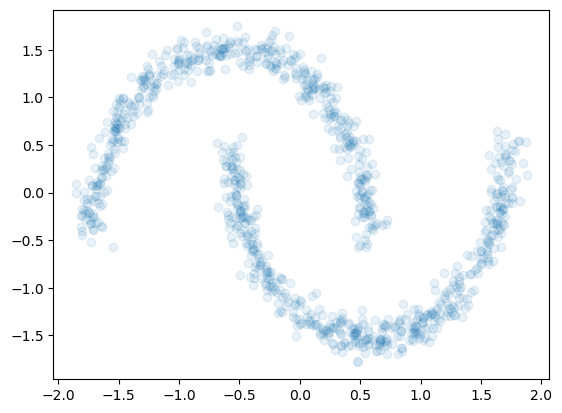

In [10]:
a = 0.1
x = integrate_sde(1000, 2, lambda x, t: drift(x, t, means, sigmas, weights, a), a)
plt.scatter(x.numpy()[:, 0], x.numpy()[:, 1], alpha=0.1)

In [11]:
import lightning as L
from torch.utils.data import DataLoader

from diffusion_rl.models.off_policy import InterpolatingNumpyDataset, OffPolicyValue
from diffusion_rl.modules.resnet_mlp import ValueNetwork

In [46]:
a = 1
moon_dataset = InterpolatingNumpyDataset(moons_generator, a=a, batch_size=1024)
moon_dataloader = DataLoader(moon_dataset, batch_size=256)

mse_value_module = ValueNetwork(2)
mse_off_policy_model = OffPolicyValue(
    base_score_module=lambda x, t: drift(x, t, means, sigmas, weights, a=a).to(
        dtype=torch.float
    ),
    value_module=mse_value_module,
    reward_function=lambda x: (
        -100 * (x - torch.tensor([[1, 0]]).to(x)).square().sum(dim=1)
    ),
    a=a,
    lr=1e-2,
    grad_decay=1e-8,
)

In [47]:
trainer = L.Trainer(max_time={"minutes": 3}, val_check_interval={"minutes": 1})
trainer.fit(
    mse_off_policy_model,
    moon_dataloader,
)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name         | Type         | Params | Mode  | FLOPs
--------------------------------------------------------------
0 | value_module | ValueNetwork | 2.9 M  | train | 0    
--------------------------------------------------------------
2.9 M     Trainable params
0         Non-trainable params
2.9 M     Total params
11.571    Total estimated model params size (MB)
45        Modules in train mode
0         Modules in eval mode
0         Total Flops
/Users/dlibland/miniforge3/envs/diffusion_rl/lib/python3.14/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/dlibland/miniforge3

Training: |          | 0/? [00:00<?, ?it/s]

Time limit reached. Elapsed time is 0:03:00. Signaling Trainer to stop.


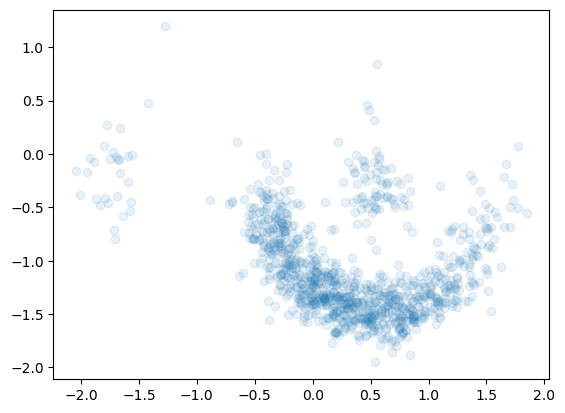

In [48]:
x = integrate_sde(
    1000, 2, lambda x, t: mse_off_policy_model.drift(x, t, 100), a=a, n_steps=100
)
plt.scatter(x.numpy()[:, 0], x.numpy()[:, 1], alpha=0.1)

In [39]:
a = 1
moon_dataset = InterpolatingNumpyDataset(moons_generator, a=a, batch_size=1024)
moon_dataloader = DataLoader(moon_dataset, batch_size=256)

quad_value_module = ValueNetwork(2)
quad_off_policy_model = OffPolicyValue(
    base_score_module=lambda x, t: drift(x, t, means, sigmas, weights, a=a).to(
        dtype=torch.float
    ),
    value_module=quad_value_module,
    reward_function=lambda x: (
        -100 * (x - torch.tensor([[1, 0]]).to(x)).square().sum(dim=1)
    ),
    a=a,
    lr=1e-2,
    loss_type="quad",
    grad_decay=1e-8,
)

trainer = L.Trainer(max_time={"minutes": 3}, val_check_interval={"minutes": 1})
trainer.fit(
    quad_off_policy_model,
    moon_dataloader,
)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name         | Type         | Params | Mode  | FLOPs
--------------------------------------------------------------
0 | value_module | ValueNetwork | 2.9 M  | train | 0    
--------------------------------------------------------------
2.9 M     Trainable params
0         Non-trainable params
2.9 M     Total params
11.571    Total estimated model params size (MB)
45        Modules in train mode
0         Modules in eval mode
0         Total Flops
/Users/dlibland/miniforge3/envs/diffusion_rl/lib/python3.14/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/dlibland/miniforge3

Training: |          | 0/? [00:00<?, ?it/s]

Time limit reached. Elapsed time is 0:03:00. Signaling Trainer to stop.


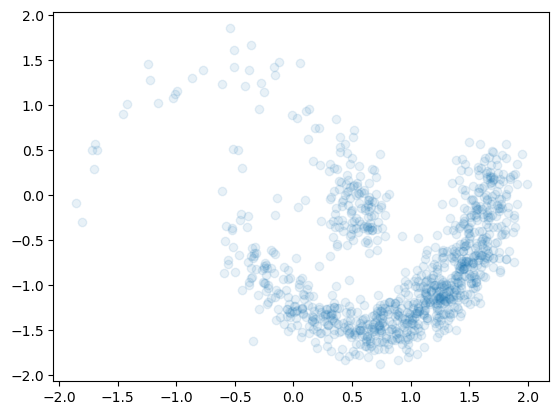

In [45]:
x = integrate_sde(
    1000, 2, lambda x, t: quad_off_policy_model.drift(x, t, 100), a=a, n_steps=100
)
plt.scatter(x.numpy()[:, 0], x.numpy()[:, 1], alpha=0.1)

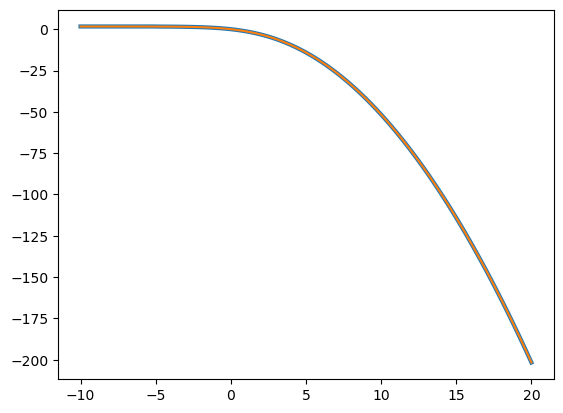

In [17]:
import numpy as np
from scipy.special import spence

from diffusion_rl.algorithms.spence import Spence1mExp

x = np.linspace(-10, 20, 100)
y_ = Spence1mExp.apply(torch.from_numpy(x)).numpy()
y_scipy = spence(np.exp(x))


plt.plot(x, y_, lw=3)
plt.plot(x, y_scipy)
# plt.yscale("log")

(0.0, 10.0)

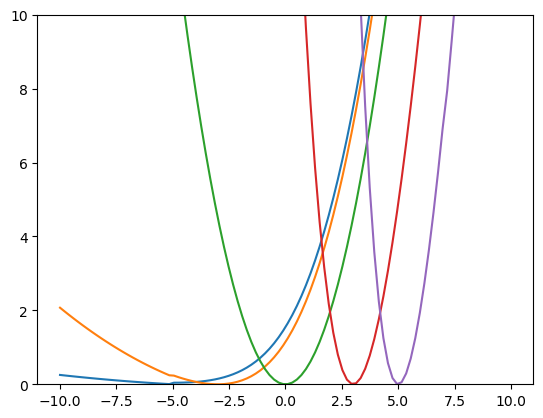

In [18]:
import torch
from matplotlib import pyplot as plt
from scipy.special import spence

from diffusion_rl.losses.log_quadratic_bregman import log_quadratic_bregman_divergence

x = torch.linspace(-10, 10, 100)
for v in [-5, -3, 0, 3, 5]:
    target = torch.ones_like(x) * v
    y = log_quadratic_bregman_divergence(x, target)
    plt.plot(x.numpy(), y.numpy())
plt.ylim(0, 10)